In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

# The error message indicates the dataset files are available at this path.
dataset_path = '/kaggle/input/netflix-movies-and-tv-shows-dataset'

# List the files in the dataset directory to identify the correct file name
print(f"Files available in the dataset directory '{dataset_path}':")
for root, dirs, files in os.walk(dataset_path):
    for name in files:
        print(os.path.join(root, name))

# Placeholder for file_path, will be updated once the correct file is identified
file_path = "netflix_titles.csv.csv"

# Load the latest version (this part will be executed after identifying the correct file)
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "thedrzee/netflix-movies-and-tv-shows-dataset",
  file_path,
)

Files available in the dataset directory '/kaggle/input/netflix-movies-and-tv-shows-dataset':
/kaggle/input/netflix-movies-and-tv-shows-dataset/netflix_titles.csv.csv


/tmp/ipython-input-3473662662.py:20: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'netflix-movies-and-tv-shows-dataset' dataset.


In [ ]:
print("First 5 rows of the DataFrame:")
display(df.head())

print("\nDataFrame Info:")
df.info()

First 5 rows of the DataFrame:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

print("Missing values in each column:")
display(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

Missing values in each column:


,Missing Count,Missing Percentage
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064


In [ ]:
import numpy as np
import pandas as pd

# Handle missing values
# 1. Fill missing values in 'director', 'cast', 'country', and 'rating' with 'Unknown'
for col in ['director', 'cast', 'country', 'rating']:
    df[col] = df[col].fillna('Unknown')

# 2. Drop rows with missing 'date_added' or 'duration' values
df.dropna(subset=['date_added', 'duration'], inplace=True)

# 3. Create a new numerical column `duration_numeric`
# Function to extract numeric part from duration
def extract_numeric_duration(duration_str):
    if pd.isna(duration_str): # Check for NaN values explicitly
        return np.nan
    parts = duration_str.split(' ')
    if parts and parts[0].isdigit():
        return int(parts[0])
    return np.nan

df['duration_numeric'] = df['duration'].apply(extract_numeric_duration)

# 4. Convert the new `duration_numeric` column to an integer type
df['duration_numeric'] = df['duration_numeric'].astype(int)

print("Data preprocessing complete. Missing values handled and 'duration_numeric' column created.")
print("Info of the DataFrame after preprocessing:")
df.info()
print("First 5 rows of the DataFrame after preprocessing:")
display(df.head())

Data preprocessing complete. Missing values handled and 'duration_numeric' column created.
Info of the DataFrame after preprocessing:
<class 'pandas.core.frame.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   show_id           8794 non-null   object
 1   type              8794 non-null   object
 2   title             8794 non-null   object
 3   director          8794 non-null   object
 4   cast              8794 non-null   object
 5   country           8794 non-null   object
 6   date_added        8794 non-null   object
 7   release_year      8794 non-null   int64 
 8   rating            8794 non-null   object
 9   duration          8794 non-null   object
 10  listed_in         8794 non-null   object
 11  description       8794 non-null   object
 12  duration_numeric  8794 non-null   int64 
dtypes: int64(2), object(11)
memory usage: 961.8+ KB
First 5 rows of the D

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_numeric
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2


In [ ]:
print("Numerical Columns:")
print(df[['release_year', 'duration_numeric']].head())

print("\nCategorical Column:")
print(df['type'].head())

print("\nNumerical columns identified: 'release_year' and 'duration_numeric'")
print("Categorical column identified: 'type'")

Numerical Columns:
   release_year  duration_numeric
0          2020                90
1          2021                 2
2          2021                 1
3          2021                 1
4          2021                 2

Categorical Column:
0      Movie
1    TV Show
2    TV Show
3    TV Show
4    TV Show
Name: type, dtype: object

Numerical columns identified: 'release_year' and 'duration_numeric'
Categorical column identified: 'type'


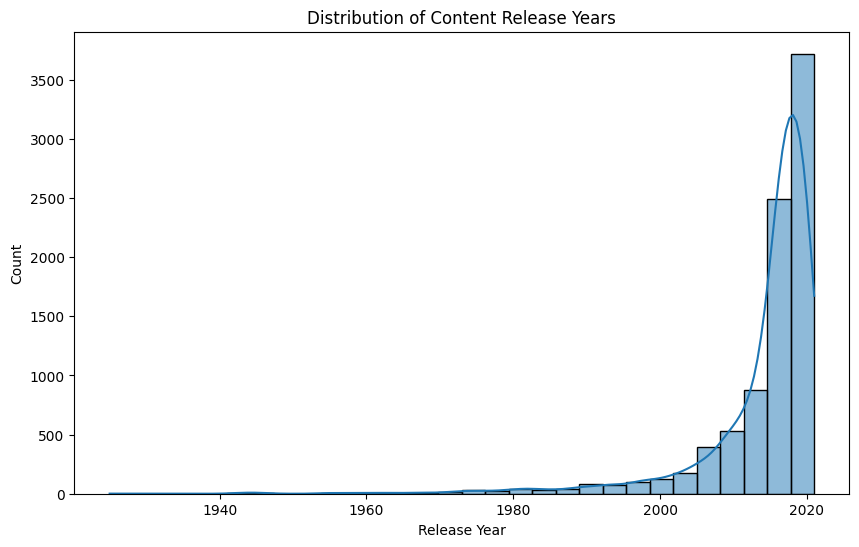

Histogram with KDE for content release years displayed.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['release_year'], kde=True, bins=30)
plt.title('Distribution of Content Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()
print("Histogram with KDE for content release years displayed.")

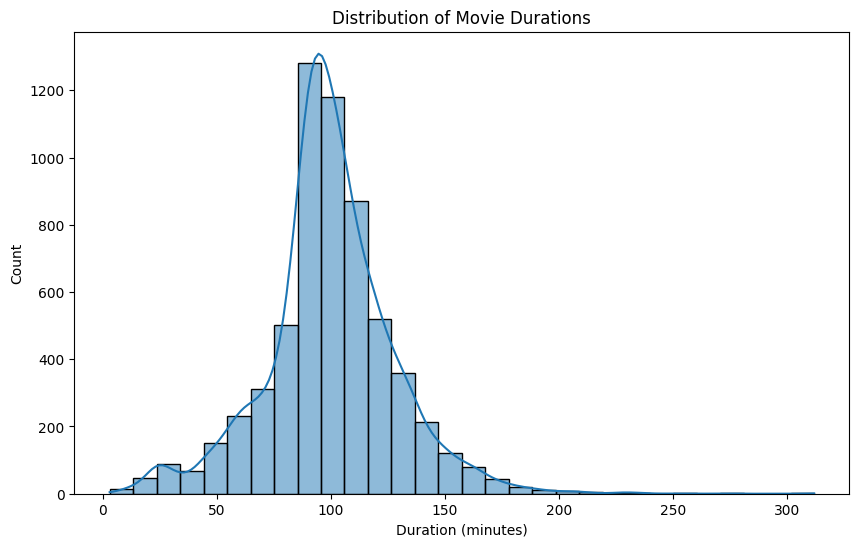

Histogram with KDE for movie durations displayed.


In [ ]:
movies_df = df[df['type'] == 'Movie']

plt.figure(figsize=(10, 6))
sns.histplot(movies_df['duration_numeric'], kde=True, bins=30)
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.show()
print("Histogram with KDE for movie durations displayed.")

/tmp/ipython-input-3972806374.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='viridis')


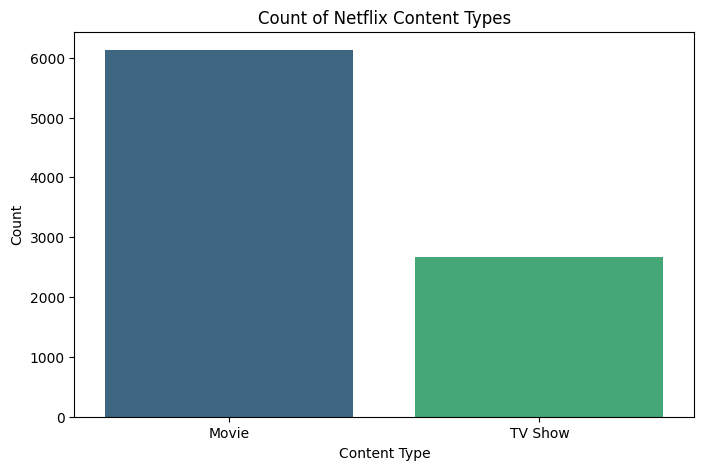

Bar plot for content types displayed.


In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='type', palette='viridis')
plt.title('Count of Netflix Content Types')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()
print("Bar plot for content types displayed.")

/tmp/ipython-input-105345164.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')


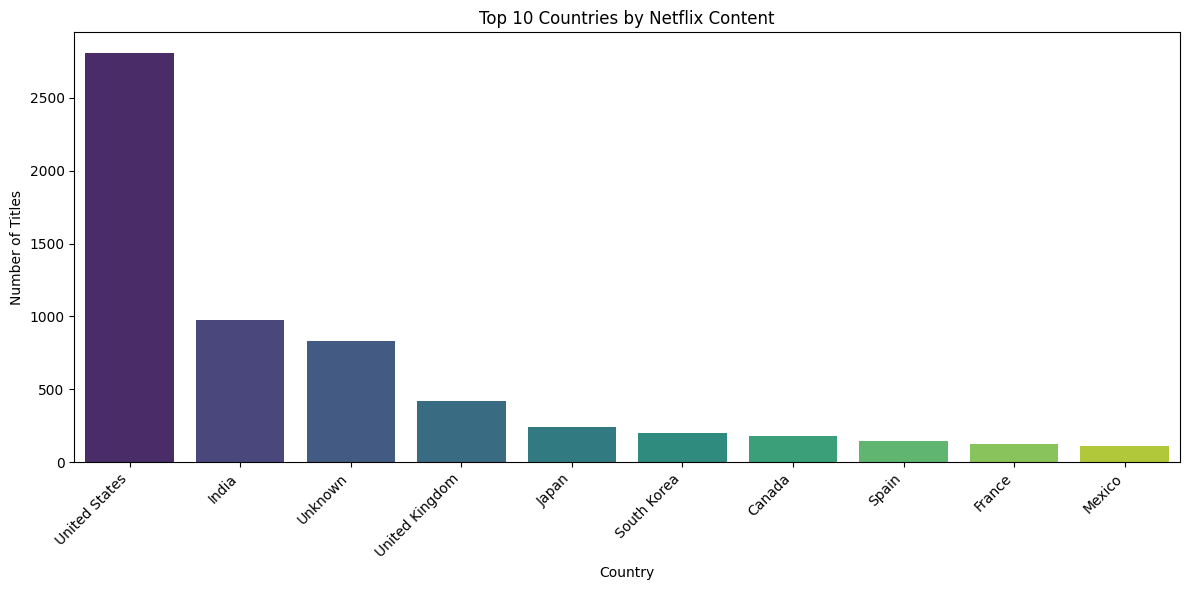

Bar plot for top 10 countries by content displayed.


In [ ]:
country_counts = df['country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis')
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Bar plot for top 10 countries by content displayed.")

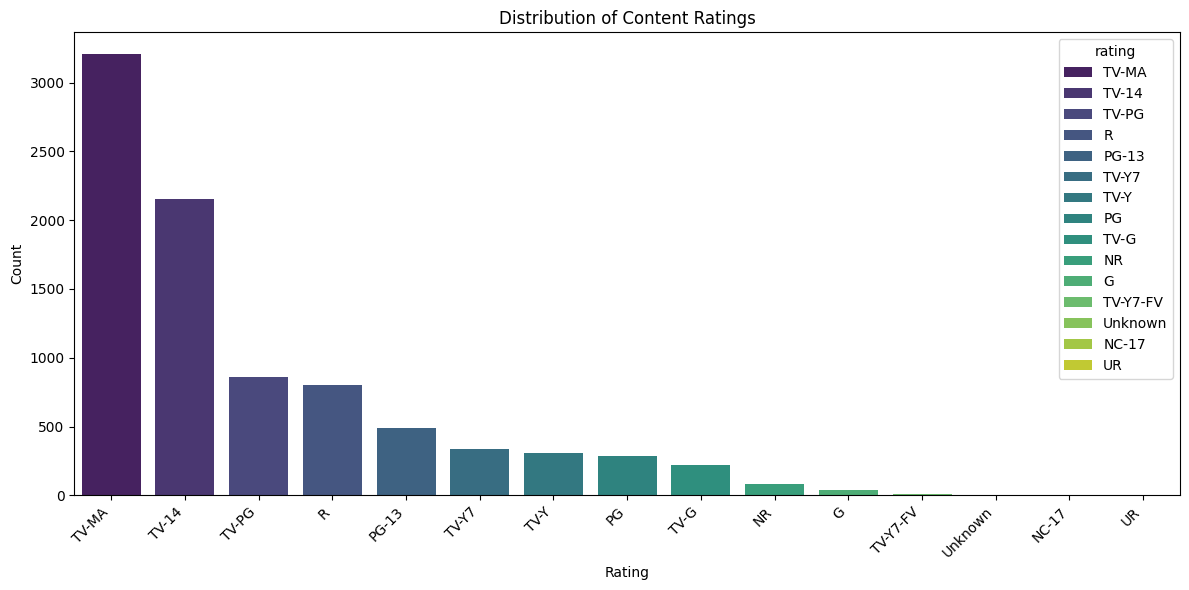

Bar plot for content ratings displayed.


In [ ]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, hue=rating_counts.index, palette='viridis', legend=True)
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Bar plot for content ratings displayed.")

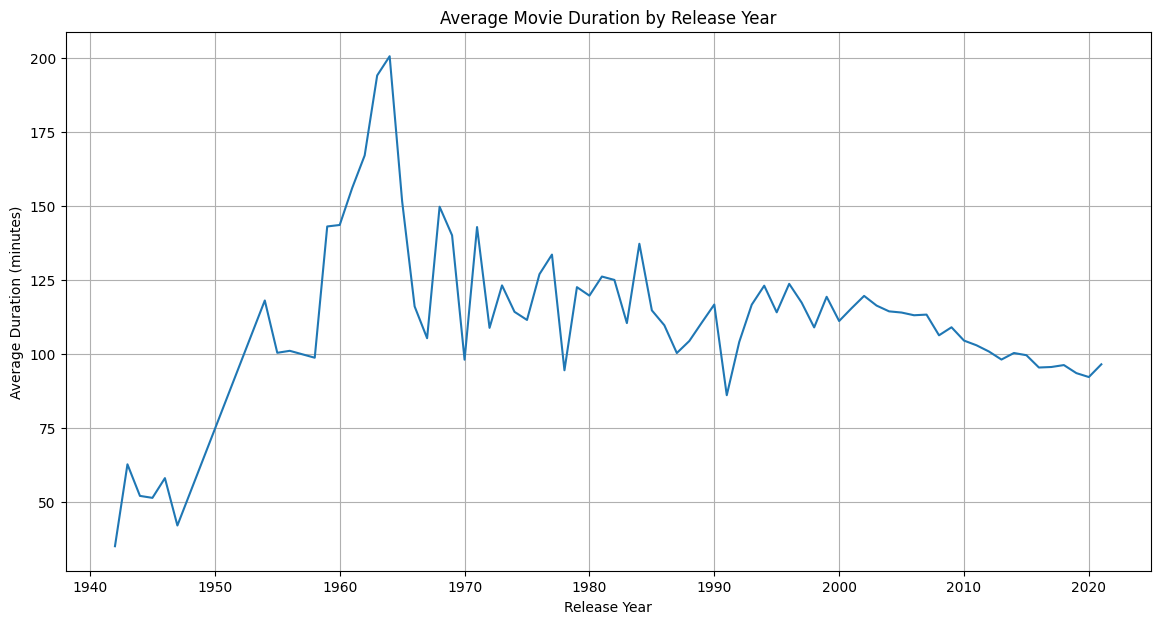

Line plot showing average movie duration by release year displayed.


In [ ]:
avg_movie_duration_by_year = movies_df.groupby('release_year')['duration_numeric'].mean()

plt.figure(figsize=(14, 7))
sns.lineplot(x=avg_movie_duration_by_year.index, y=avg_movie_duration_by_year.values)
plt.title('Average Movie Duration by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (minutes)')
plt.grid(True)
plt.show()
print("Line plot showing average movie duration by release year displayed.")